# 03 · Capex panel EDA

Closes out the data pipeline before model evaluation. Read-only: it reads
`data/processed/` only and writes nothing.

The dependent variable changed between notebook 02 and this one. Notebook 02
tested national production growth against **announcement counts** and found the
sample too small to power a lead test. This notebook uses **company capex**
instead, rebuilt from filed cash-flow statements — 182 company-years against 16
usable events.

The headline is not the row count. It is that the extra rows do not buy what the
project needs, and that the specifications which *are* properly identified all
come back null. Working through that is the point of this notebook, because it
decides what model evaluation should attempt.

**Outline**

1. Load the panels
2. Panel coverage — effective T, not row count
3. Y is heavy-tailed, so scale it
4. Validating a sub-annual capex proxy
5. Acquisition screen
6. The primary design (national X) is structurally untestable
7. The identified design (own X, within company)
8. Robustness: production instead of registrations
9. Lead structure
10. Negative control, and a common sector cycle
11. The cross-sectional fallback
12. Where this leaves model evaluation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

# find the data folder whether we run from repo root or notebook-590/
DATA = Path("data") if Path("data").exists() else Path("../data")

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

## 1. Load the panels

In [2]:
ann  = pd.read_csv(DATA / "processed/panel_company_annual.csv", parse_dates=["period_end"])
half = pd.read_csv(DATA / "processed/panel_company_halfyearly.csv", parse_dates=["period_end"])
tgt  = pd.read_csv(DATA / "manual/target_companies.csv")

# primary_panel excludes upstream materials and out-of-scope names; see data/README.md
ann_p  = ann[ann.primary_panel == "yes"].copy()
half_p = half[half.primary_panel == "yes"].copy()

print(f"annual      {len(ann):>4} rows, {ann.nse_symbol.nunique():>2} firms "
      f"({len(ann_p)} in the primary panel)")
print(f"half-yearly {len(half):>4} rows, {half.nse_symbol.nunique():>2} firms "
      f"({len(half_p)} in the primary panel)")
print(f"target list {len(tgt):>4} companies, {(tgt.primary_panel == 'yes').sum()} in the panel")
tgt.tier.value_counts()

annual       182 rows, 47 firms (139 in the primary panel)
half-yearly  204 rows, 35 firms (204 in the primary panel)
target list   52 companies, 36 in the panel


tier
ev_component         26
upstream_material     9
oem_ev_led            5
oem_ice_led           4
oem_ev_pure           3
battery_cell          2
out_of_scope          2
charging              1
Name: count, dtype: int64

## 2. Panel coverage — effective T, not row count

The independent variable comes at two levels. `national_*` is one series shared by
every company in a period, so however many companies are stacked, the number of
*distinct* X values equals the number of periods. `own_ev_registrations` is a
company's own monthly EV volume, so it varies across company **and** time.

The `distinct X` column below is the one that matters — it is what a regression
can actually identify from.

In [3]:
designs = [
    ("annual",      ann_p,  "national_ev_production"),
    ("annual",      ann_p,  "national_ev_registrations"),
    ("annual",      ann_p,  "own_ev_registrations"),
    ("annual",      ann_p,  "own_ev_production"),
    ("half-yearly", half_p, "national_ev_production"),
    ("half-yearly", half_p, "own_ev_registrations"),
    ("half-yearly", half_p, "own_ev_production"),
]
rows = []
for freq, df, x in designs:
    u = df[df[x].notna()]
    rows.append({"frequency": freq, "X": x, "n": len(u),
                 "firms": u.nse_symbol.nunique(),
                 "distinct X": u[x].nunique(),
                 "periods": u.period_end.nunique()})
pd.DataFrame(rows)

,frequency,X,n,firms,distinct X,periods
0,annual,national_ev_production,104,36,5,5
1,annual,national_ev_registrations,139,36,8,8
2,annual,own_ev_registrations,17,6,17,3
3,annual,own_ev_production,12,4,12,3
4,half-yearly,national_ev_production,202,35,15,11
5,half-yearly,own_ev_registrations,31,6,31,6
6,half-yearly,own_ev_production,24,4,24,6


Read `distinct X` against `n`. In the national designs it tracks the number of
periods, not the number of rows: 5 values across 104 rows, 8 across 139. That is
the tell — stacking 36 firms against a shared series gives 36 copies of the same
handful of values. (Half-yearly national production shows 15 rather than 11
because the non-March filers sum the same series over shifted windows, which adds
variants of one series rather than independent observations.) In the
own-registrations designs `distinct X` equals `n` exactly: every row is a
genuinely different observation.

So the 139-row national panel is, for identification, a 4-to-8 point time series.
The 31-row own-X panel is a real panel. That asymmetry drives everything below.

One caveat on the period counts: they are inflated by filers that do not close in
March. CIE Automotive closes in December and Hyundai files December and June
periods. Restricted to March filers the annual panel has exactly four.

In [4]:
mar = ann_p[ann_p.period_end.dt.month == 3].copy()
mar["fy"] = mar.period_end.dt.year
print(f"March filers only: {len(mar)} rows, {mar.nse_symbol.nunique()} firms, "
      f"{mar.period_end.nunique()} periods -> {sorted(mar.period_end.dt.year.unique())}")
print(f"  of which carry national production X: {mar.national_ev_production.notna().sum()} "
      f"rows over {mar[mar.national_ev_production.notna()].period_end.nunique()} periods")

March filers only: 135 rows, 35 firms, 4 periods -> [np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
  of which carry national production X: 102 rows over 3 periods


## 3. Y is heavy-tailed, so scale it

Capex in rupees is not comparable across a panel spanning Mahindra and PPAP
Automotive. A pooled regression on raw `capex_cr` is a regression on company
size.

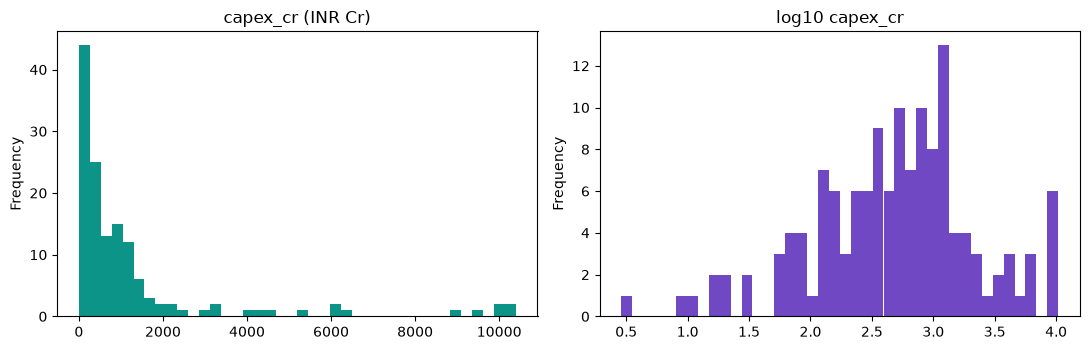

min         2.9
50%       530.3
mean     1292.9
max     10392.0
max/median = 20x


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ann_p.capex_cr.plot.hist(bins=40, ax=ax[0], color="#0D9488")
ax[0].set_title("capex_cr (INR Cr)"); ax[0].set_xlabel("")
np.log10(ann_p.capex_cr.clip(lower=1)).plot.hist(bins=40, ax=ax[1], color="#7048C4")
ax[1].set_title("log10 capex_cr"); ax[1].set_xlabel("")
plt.tight_layout(); plt.show()

print(ann_p.capex_cr.describe()[["min", "50%", "mean", "max"]].round(1).to_string())
print(f"max/median = {ann_p.capex_cr.max() / ann_p.capex_cr.median():.0f}x")

In [6]:
ann_p["capex_over_cfo"] = ann_p.capex_cr / ann_p.cfo_cr.where(ann_p.cfo_cr > 0)
ann_p["capex_over_dep"] = ann_p.capex_cr / ann_p.depreciation_cr.where(ann_p.depreciation_cr > 0)

print(ann_p[["capex_over_cfo", "capex_over_dep"]].describe()
      .loc[["count", "mean", "50%", "std"]].round(2).to_string())
bad = ann_p[ann_p.cfo_cr <= 0]
print(f"\n{len(bad)} company-years have non-positive operating cash flow, so "
      f"capex/CFO is undefined for them:")
print("  " + ", ".join(sorted(bad.nse_symbol.unique())))

       capex_over_cfo  capex_over_dep
count          124.00          139.00
mean             0.87            2.03
50%              0.56            1.70
std              1.38            1.53

15 company-years have non-positive operating cash flow, so capex/CFO is undefined for them:
  ASHOKLEY, EXICOM, M&M, OLAELEC, SYRMA, TVSMOTOR


`capex/CFO` is the more natural scaler but it breaks on 15 company-years with
negative operating cash flow — and those are not marginal firms: Ola, TVS,
Mahindra, Ashok Leyland. `capex/depreciation` is defined everywhere and has a
clean reading: above 1 the company is expanding its asset base rather than just
replacing it. **Prefer `capex/depreciation`,** with log capex plus company fixed
effects as the alternative.

## 4. Validating a sub-annual capex proxy

Filed capex is annual; the balance sheet lands twice a year. If a stock change can
stand in for capex, the panel gains the time resolution section 2 showed is the
binding constraint.

The naive version fails, and it is worth seeing why. A stock change is a **net**
number (capex minus depreciation, plus anything acquired); filed capex is
**gross**.

In [7]:
stock = half.set_index(["nse_symbol", "period_end"])["productive_assets_cr"].sort_index()

m = ann.copy()
m["prior_end"]    = m.period_end - pd.DateOffset(years=1)
m["stock_now"]    = [stock.get((s, d), np.nan) for s, d in zip(m.nse_symbol, m.period_end)]
m["stock_prior"]  = [stock.get((s, d), np.nan) for s, d in zip(m.nse_symbol, m.prior_end)]
m["delta_assets"] = m.stock_now - m.stock_prior
m = m[m.delta_assets.notna() & m.capex_cr.notna() & m.depreciation_cr.notna()]

print(f"n = {len(m)} company-years with both an annual stock change and filed capex\n")
print(f"  corr(delta assets,                capex) = {m.delta_assets.corr(m.capex_cr):.3f}")
print(f"  corr(delta assets + depreciation, capex) = "
      f"{(m.delta_assets + m.depreciation_cr).corr(m.capex_cr):.3f}   <-- add depreciation back")

n = 65 company-years with both an annual stock change and filed capex

  corr(delta assets,                capex) = 0.697
  corr(delta assets + depreciation, capex) = 0.900   <-- add depreciation back


Adding depreciation back lifts the correlation from **0.70 to 0.90**. The pipeline
computes this as `asset_formation_cr` on the annual panel, with median absolute
error against filed capex of about **17%**.

Maruti FY26 is the clean illustration: it spent 10,123 Cr while its asset stock
rose only 3,450, because depreciation consumed the rest. Neither number is wrong —
they measure different things.

n = 97   corr = 0.896   median |error| = 16.7%


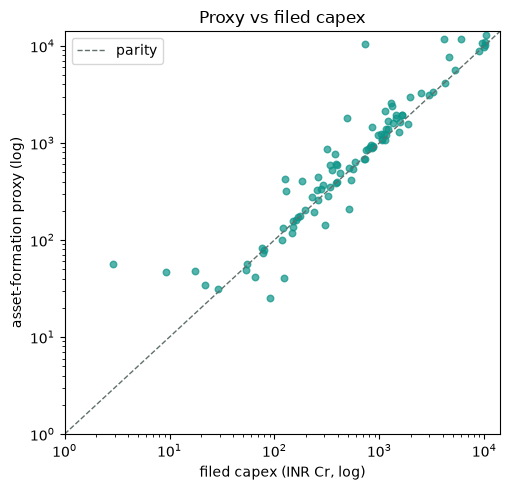

In [8]:
v = ann[ann.asset_formation_cr.notna() & (ann.capex_cr > 0)]
print(f"n = {len(v)}   corr = {v.asset_formation_cr.corr(v.capex_cr):.3f}   "
      f"median |error| = {v.asset_formation_error_pct.abs().median():.1f}%")

fig, ax = plt.subplots(figsize=(5.2, 5))
ax.scatter(v.capex_cr, v.asset_formation_cr, s=22, alpha=.7, color="#0D9488")
lim = [1, max(v.capex_cr.max(), v.asset_formation_cr.max()) * 1.1]
ax.plot(lim, lim, "--", color="#5F706D", lw=1, label="parity")
ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("filed capex (INR Cr, log)"); ax.set_ylabel("asset-formation proxy (log)")
ax.legend(); ax.set_title("Proxy vs filed capex"); plt.tight_layout(); plt.show()

## 5. Acquisition screen

The residual from section 4 is informative rather than noise. Where the proxy
exceeds filed capex by more than 100%, the company grew its asset base by
**buying** it rather than building it. For a question about *new manufacturing
investment* that distinction is substantive, so the pipeline flags those rows
instead of smoothing them.

In [9]:
ann[ann.formation_flag.notna()].sort_values("asset_formation_error_pct", ascending=False)[
    ["nse_symbol", "period_end", "tier", "capex_cr", "asset_formation_cr",
     "asset_formation_error_pct", "formation_flag"]]

,nse_symbol,period_end,tier,capex_cr,asset_formation_cr,asset_formation_error_pct,formation_flag
115,PPAP,2026-03-31,ev_component,2.8945,56.9673,1868.12,acquired
14,BAJAJ-AUTO,2026-03-31,oem_ev_led,722.3200,10389.3500,1338.33,acquired
114,PPAP,2025-03-31,ev_component,9.3447,47.2980,406.15,acquired
139,SONACOMS,2026-03-31,ev_component,491.8380,1814.1470,268.85,acquired
81,JWL,2024-03-31,ev_component,124.8188,420.9386,237.24,acquired
125,MOTHERSON,2024-03-31,ev_component,4125.4000,11804.9400,186.15,acquired
38,EXICOM,2024-03-31,charging,17.5124,48.4404,176.61,acquired
137,SONACOMS,2024-03-31,ev_component,319.5310,855.6650,167.79,acquired
40,EXICOM,2026-03-31,charging,128.7669,318.7729,147.56,acquired
151,SYRMA,2026-03-31,ev_component,183.5100,404.3490,120.34,acquired


These are real acquirers: Bajaj consolidated its KTM holding in FY26 (stock
+9,745 Cr on 722 Cr of capex), Motherson is habitually acquisitive, Sona BLW
bought in FY24 and FY26. **PPAP is a denominator artefact** — filed capex of 3 Cr
makes any absolute gap enormous in percentage terms, so treat its flag as noise.

Any model on the half-yearly panel should exclude or dummy these. Bajaj's FY26
half-year shows 262% asset growth (z = 5.2) and would dominate an unweighted
regression by itself.

In [10]:
own = half_p[half_p.own_ev_registrations.notna()].copy()
g = own.productive_assets_cr_growth_pct.dropna()
print(f"asset growth %: mean={g.mean():.2f}  sd={g.std():.2f}\n")
print(own.loc[g.abs().sort_values(ascending=False).index]
         .head(4)[["nse_symbol", "window_start", "window_end", "window_months",
                   "productive_assets_cr_growth_pct"]].to_string(index=False))
print(f"\nwindow lengths present: {sorted(own.window_months.unique())} -- Ola's "
      "balance-sheet history skips a period, leaving one 9-month window that is "
      "not comparable to a 6-month one.")

asset growth %: mean=15.79  sd=47.66

nse_symbol window_start window_end  window_months  productive_assets_cr_growth_pct
BAJAJ-AUTO      2025-10    2026-03              6                         262.4587
   OLAELEC      2023-07    2024-03              9                          72.4834
  TVSMOTOR      2024-10    2025-03              6                          25.3535
   OLAELEC      2024-10    2025-03              6                          13.8807

window lengths present: [np.int64(6), np.int64(9)] -- Ola's balance-sheet history skips a period, leaving one 9-month window that is not comparable to a 6-month one.


## 6. The primary design (national X) is structurally untestable

The project's primary question pairs national EV production growth against
investment. With capex filed annually, here is the entire available overlap.

In [11]:
agg = (mar.groupby("fy")
          .agg(panel_capex_cr=("capex_cr", "sum"),
               national_production=("national_ev_production", "first"),
               national_registrations=("national_ev_registrations", "first"),
               firms=("nse_symbol", "nunique")))
agg

,panel_capex_cr,national_production,national_registrations,firms
fy,,,,
2023,29808.1573,NaN,1222589,33
2024,42510.1466,494210.0,1741465,34
2025,52841.1570,827205.0,2039293,35
2026,52760.0243,1252921.0,2547083,33


In [12]:
both = agg.dropna(subset=["national_production"])
print(f"periods with capex AND national production: {len(both)}")
print(f"a lead test consumes one period, leaving {len(both) - 1} usable pairs")
n_reg = agg.national_registrations.notna().sum()
print(f"\nwith national registrations instead (they reach back to 2018): "
      f"{n_reg} periods, {n_reg - 1} usable pairs after one lag")

periods with capex AND national production: 3
a lead test consumes one period, leaving 2 usable pairs

with national registrations instead (they reach back to 2018): 4 periods, 3 usable pairs after one lag


**Two to three usable pairs.** No estimator recovers a lead from that, and extra
companies change nothing because every company shares the same X. This is the
constraint notebook 02's power simulation was pointing at, arriving from the other
side: then the dependent variable was too sparse, now the independent variable is
too coarse. Swapping in national registrations buys one extra period, not a
design.

## 7. The identified design (own X, within company)

Six companies have both their own monthly EV volume series and filed financials
(the seventh, Ather, has no filing history). Within-company demeaning removes firm
scale, leaving the question: when *this* company's EV volume grows faster than its
own average, does its asset base grow faster than its own average?

In [13]:
def within_demean(df, xcol, ycol, drop=()):
    d = df[~df.nse_symbol.isin(drop)][["nse_symbol", xcol, ycol]].dropna()
    d = d[d.groupby("nse_symbol")[xcol].transform("size") >= 2]
    out = d.copy()
    for c in (xcol, ycol):
        out[c] = d[c] - d.groupby("nse_symbol")[c].transform("mean")
    return out

def fit(d, xcol, ycol, label):
    if len(d) < 4:
        print(f"{label:<42} n={len(d)} too few")
        return
    res = sm.OLS(d[ycol], sm.add_constant(d[xcol])).fit()
    print(f"{label:<42} n={len(d):>2}  firms={d.nse_symbol.nunique()}  "
          f"beta={res.params[xcol]:>8.4f}  t={res.tvalues[xcol]:>6.2f}  "
          f"R2={res.rsquared:.3f}  r={d[xcol].corr(d[ycol]):>6.3f}")

X, Y = "own_ev_reg_growth_pct", "productive_assets_cr_growth_pct"
print("HALF-YEARLY: own EV volume growth -> own productive-asset growth\n")
fit(within_demean(own, X, Y), X, Y, "all firms")
fit(within_demean(own, X, Y, drop=("TMCV",)), X, Y, "excl. TMCV (entity mismatch)")
fit(within_demean(own, X, Y, drop=("TMCV", "BAJAJ-AUTO")), X, Y,
    "excl. TMCV + Bajaj (FY26 consolidation)")

HALF-YEARLY: own EV volume growth -> own productive-asset growth

all firms                                  n=24  firms=5  beta= -0.0030  t= -0.01  R2=0.000  r=-0.003
excl. TMCV (entity mismatch)               n=24  firms=5  beta= -0.0030  t= -0.01  R2=0.000  r=-0.003
excl. TMCV + Bajaj (FY26 consolidation)    n=19  firms=4  beta=  0.0164  t=  0.66  R2=0.025  r= 0.158


Nothing. The contemporaneous within-company relationship is **r = -0.003**
(beta = -0.003, t = -0.01). Dropping Bajaj's consolidation moves it to r = 0.16,
t = 0.66 — still indistinguishable from zero.

Dropping TMCV changes the numbers not at all, because Tata Motors contributes only
two periods and the >=2-observation rule already excludes it. It is worth dropping
on substantive grounds regardless: registrations under "TATA MOTORS" are
overwhelmingly 4W passenger EVs, while the financials under the `TMCV` ISIN are the
**commercial vehicle** entity created by the demerger. X and Y describe different
businesses.

Same test with annual capex as Y — cleaner dependent variable, fewer periods:

In [14]:
own_a = ann_p[ann_p.own_ev_registrations.notna()].copy()
print("ANNUAL: own EV volume growth -> own capex growth\n")
fit(within_demean(own_a, X, "capex_cr_growth_pct"), X, "capex_cr_growth_pct", "all firms")

ANNUAL: own EV volume growth -> own capex growth

all firms                                  n=10  firms=5  beta=  0.0967  t=  0.41  R2=0.021  r= 0.144


n = 10, r = 0.14, t = 0.41. Also null, and far too small to be evidence either
way.

## 8. Robustness: production instead of registrations

Section 6 used **registrations** as each company's own volume. The research
question names **production**, and the two are not the same thing: registrations
lag manufacture, are recorded where the vehicle is bought rather than built, and
exclude exports entirely. If the null is an artefact of that substitution, it
matters.

`own_ev_production` is built from the SIAM feed for the four panel firms that
report EV production there — Bajaj, Hero, Mahindra and TVS. Ola and Tata Motors
are absent from that source, which is the documented consequence of it classifying
passenger vehicles by length and price rather than by powertrain. Losing Ola is the
real cost: its volumes fall steadily across the window and supply most of the
variation in the registrations test.

So the comparison has to be **like for like** — the same four firms, both measures
— or it confounds a change of variable with a change of sample.

In [15]:
Y  = "productive_assets_cr_growth_pct"
XR = "own_ev_reg_growth_pct"
XP = "own_ev_prod_growth_pct"
four = ["BAJAJ-AUTO", "HEROMOTOCO", "M&M", "TVSMOTOR"]

print("HALF-YEARLY: own X -> own productive-asset growth\n")
fit(within_demean(own, XR, Y), XR, Y, "registrations (all 6 firms)")
fit(within_demean(own, XP, Y), XP, Y, "PRODUCTION (4 firms)")
fit(within_demean(own, XP, Y, drop=("BAJAJ-AUTO",)), XP, Y,
    "PRODUCTION excl. Bajaj (FY26 consolidation)")
fit(within_demean(own[own.nse_symbol.isin(four)], XR, Y), XR, Y,
    "registrations, SAME 4 firms (like-for-like)")

print("\nANNUAL: own X -> own capex growth\n")
fit(within_demean(own_a, XR, "capex_cr_growth_pct"), XR, "capex_cr_growth_pct",
    "registrations")
fit(within_demean(own_a, XP, "capex_cr_growth_pct"), XP, "capex_cr_growth_pct",
    "PRODUCTION")

agree = own[[XR, XP]].dropna()
print(f"\nthe two own-X measures agree only moderately: n={len(agree)}, "
      f"r={agree[XR].corr(agree[XP]):.3f}")

HALF-YEARLY: own X -> own productive-asset growth

registrations (all 6 firms)                n=24  firms=5  beta= -0.0030  t= -0.01  R2=0.000  r=-0.003
PRODUCTION (4 firms)                       n=20  firms=4  beta=  0.0970  t=  0.29  R2=0.005  r= 0.068
PRODUCTION excl. Bajaj (FY26 consolidation) n=15  firms=3  beta= -0.0235  t= -0.67  R2=0.033  r=-0.181
registrations, SAME 4 firms (like-for-like) n=20  firms=4  beta= -0.0037  t= -0.02  R2=0.000  r=-0.004

ANNUAL: own X -> own capex growth

registrations                              n=10  firms=5  beta=  0.0967  t=  0.41  R2=0.021  r= 0.144
PRODUCTION                                 n= 8  firms=4  beta=  0.0129  t=  0.07  R2=0.001  r= 0.029

the two own-X measures agree only moderately: n=20, r=0.452


**The null survives the swap, and the like-for-like row is the one to read.** On
the same four firms, registrations give r = -0.004 and production gives r = +0.068
— both indistinguishable from zero, and the gap between them smaller than the
noise. Dropping Bajaj's consolidation moves production to r = -0.181, still
nothing. Annual capex against own production gives r = 0.029 on eight
observations.

Worth noting that the two measures correlate at only **r = 0.45** with each other,
so this was not a foregone conclusion — production and registrations growth
genuinely differ half-year to half-year. They simply both fail to predict capex.

The conclusion is therefore not an artefact of using registrations as a proxy for
production. It costs two firms and gains no signal.

## 9. Lead structure

The hypothesis is specifically that volume moves *first*. Own volume growth at k
periods ahead of asset growth:

In [16]:
def lead_table(xcol, drop=()):
    rows = []
    for k in (0, 1, 2):
        acc = []
        for sym, r in own[~own.nse_symbol.isin(drop)].groupby("nse_symbol"):
            r = r.sort_values("period_end")
            x, y = r[xcol].values, r[Y].values
            pairs = [(x[i], y[i + k]) for i in range(len(r) - k)
                     if np.isfinite(x[i]) and np.isfinite(y[i + k])]
            if len(pairs) >= 2:
                p = np.array(pairs, dtype=float)
                acc.append(p - p.mean(axis=0))      # demean within firm
        if acc:
            d = np.vstack(acc)
            rows.append({"k (half-years)": k, "n": len(d),
                         "within-firm r": round(
                             float(np.corrcoef(d[:, 0], d[:, 1])[0, 1]), 3)})
    return pd.DataFrame(rows).assign(X=xcol)

pd.concat([lead_table(XR, drop=("TMCV",)), lead_table(XP)], ignore_index=True)

,k (half-years),n,within-firm r,X
0,0,24,-0.003,own_ev_reg_growth_pct
1,1,19,-0.372,own_ev_reg_growth_pct
2,2,14,0.045,own_ev_reg_growth_pct
3,0,20,0.068,own_ev_prod_growth_pct
4,1,16,-0.287,own_ev_prod_growth_pct
5,2,12,-0.362,own_ev_prod_growth_pct


Both measures do the same thing. Registrations give r = -0.003 at k = 0 and
**-0.372** at k = 1; production gives +0.068 and **-0.287**. The lead correlation is
not merely absent — it is the wrong sign on both, and at n = 16–19 across three to
six firms it is not distinguishable from noise either.

Same sign-alternating pattern notebook 02 found on the national
production/registrations pair, and it reads the same way: machinery running on too
little data, not structure.

## 10. Negative control, and a common sector cycle

Precision Camshafts is in the panel deliberately as a control — camshafts are an
ICE-only part, so EV growth should not drive its capex. If it moves like the EV
names, the model is picking up the automotive cycle rather than anything
electric.

In [17]:
tier_order = ["oem_ev_pure", "oem_ev_led", "battery_cell", "ev_component",
              "oem_ice_led", "charging"]
piv = (mar[mar.tier.isin(tier_order)]
       .pivot_table(index="tier", columns="fy",
                    values="capex_cr_growth_pct", aggfunc="mean")
       .reindex(tier_order).round(1))
print("mean capex growth % by tier and fiscal year end\n")
print(piv.to_string())

pc = mar[mar.nse_symbol == "PRECAM"][["fy", "capex_cr_growth_pct"]].dropna()
print("\nPrecision Camshafts (ICE-only control):")
print("  " + ", ".join(f"{int(y)}: {v:+.1f}%" for y, v in
                       zip(pc.fy, pc.capex_cr_growth_pct)))

mean capex growth % by tier and fiscal year end

fy            2024    2025  2026
tier                            
oem_ev_pure   33.0    52.6 -18.3
oem_ev_led     9.7    37.6  18.6
battery_cell  79.7    20.8 -14.6
ev_component  77.5    37.4   7.5
oem_ice_led   32.8    37.7  19.3
charging       6.5  2094.6 -66.5

Precision Camshafts (ICE-only control):
  2024: +5.6%, 2025: -17.5%, 2026: +44.4%


Every tier shows the same shape — a large FY24 step up, a smaller FY25 one, FY26
flat or negative. Three details make this hard to read as an EV signal:

**The ICE-led OEMs grew capex faster than the EV-led ones.** `oem_ice_led` runs
+32.8 / +37.7 / +19.3 against `oem_ev_led` at +9.7 / +37.6 / +18.6. If EV volume
were driving plant investment, that ordering should be reversed.

**The EV-specific tiers are not the fast movers.** `battery_cell` grows +80% in
FY24, but `ev_component` grows +78% alongside it, and `oem_ev_pure` turns
*negative* in FY26 (-18.3%) while components are still positive.

**The ICE-only negative control does not stand apart.** Precision Camshafts makes
a part that cannot go in an EV, and its capex growth (+5.6 / -17.5 / +44.4) sits
inside the range the EV-exposed tiers occupy.

Together that is much more consistent with a **sector-wide capex cycle** than with
an EV-specific signal. It is also the confound the deck flagged for the siting
question, reappearing on the national one.

One row to disregard: `charging` is Exicom alone, and its +2,095% FY25 figure is a
384 Cr capex year against an 18 Cr one. A single firm off a tiny base is not a
tier, and no weight should be put on that line.

## 11. The cross-sectional fallback

`data/README.md` lists a third design: drop the lead question and ask whether
cumulative EV exposure predicts cumulative capex intensity. This is the
well-powered option — 35 firms, no time dimension to run out of.

In [18]:
tot = (ann_p[ann_p.capex_cr.notna()]
       .groupby(["nse_symbol", "tier"], as_index=False)
       .agg(capex=("capex_cr", "sum"), dep=("depreciation_cr", "sum"),
            years=("capex_cr", "size")))
tot = tot[(tot.years >= 3) & (tot.dep > 0)]
tot["intensity"] = tot.capex / tot.dep

print(f"n = {len(tot)} firms with >=3 years and positive depreciation\n")
print(tot.groupby("tier").intensity.agg(["size", "mean", "median"])
         .sort_values("mean", ascending=False).round(2).to_string())

ev_side = tot[tot.tier.isin(["oem_ev_pure", "oem_ev_led", "battery_cell"])].intensity
other   = tot[tot.tier.isin(["ev_component", "charging", "oem_ice_led"])].intensity
t_stat, p_val, _ = sm.stats.ttest_ind(ev_side, other, usevar="unequal")
print(f"\nEV-led/battery (n={len(ev_side)}) mean={ev_side.mean():.2f}  vs  "
      f"components/ICE-led (n={len(other)}) mean={other.mean():.2f}")
print(f"difference = {ev_side.mean() - other.mean():+.2f}   t = {t_stat:.2f}   p = {p_val:.3f}")

n = 35 firms with >=3 years and positive depreciation

              size  mean  median
tier                            
oem_ev_pure      2  2.63    2.63
charging         1  2.61    2.61
battery_cell     2  2.29    2.29
ev_component    22  2.14    1.68
oem_ev_led       4  1.67    1.79
oem_ice_led      4  1.62    1.69

EV-led/battery (n=8) mean=2.06  vs  components/ICE-led (n=27) mean=2.08
difference = -0.02   t = -0.06   p = 0.956


Also null. Capex intensity is **2.06** for the EV-led and battery names against
**2.08** for components and ICE-led ones — a difference of -0.02, t = -0.06. Every
tier sits comfortably above 1.0, so the whole sector is expanding rather than
merely replacing capacity; the EV-exposed names are not expanding faster.

## 12. Where this leaves model evaluation

The pipeline is finished and the data is sound. Three findings should shape what
gets modelled, and none is a data-quality problem.

**The primary specification cannot be estimated.** National X against annually
filed capex yields two to three usable pairs. That is a property of how capex is
filed, not of our query, and it should be reported as a design limit rather than
attempted and dressed up as a weak result.

**The identified specification returns a null, and it survives a robustness
check.** Own EV volume growth against own asset growth, within company, gives
r = -0.003 contemporaneously and r = -0.37 at a one-period lead, on 24 and 19
observations. Substituting genuine **production** for registrations on the same
four firms moves that from r = -0.004 to r = +0.068 — no material change, even
though the two measures only correlate at r = 0.45 with each other. So the null is
not an artefact of the registrations proxy. A null at n≈20 is still weak evidence,
so the honest phrasing is *underpowered and uninformative*, not *no effect exists*.
Notebook 02's power machinery is the right tool to quantify that, now against this
sample size rather than the announcement count.

**The well-powered specification also returns a null, and that one carries
weight.** The cross-sectional intensity test has 35 firms and finds no difference
between EV-exposed and other companies (t = -0.06). Combined with section 9 — the
ICE-only control moving with the EV names, all tiers sharing one FY24-peaked cycle
— the most defensible reading is that **automotive capex over FY23–FY26 was driven
by a sector-wide cycle rather than by EV volumes specifically.**

That is a real answer to the project's question, just not the one the hypothesis
predicted. Suggested scope for model evaluation:

1. **Report the sector-cycle finding as the primary result.** It rests on the
   best-powered evidence available and is falsifiable.
2. **Model the cross-section properly** — capex intensity on tier, EV exposure and
   size, with acquisition-flagged rows handled explicitly. It is the only design
   with enough observations to justify a fitted model.
3. **Present the lead test as a documented power failure,** reusing notebook 02's
   simulation with the real n. Stating how large an effect *would* have been
   detectable is a stronger contribution than a p-value on n = 19.
4. **Do not train anything on the national-X panel.** 139 rows implying power that
   four distinct X values do not provide is the one genuinely misleading thing this
   dataset could be used to do.